In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, VotingRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
#  Load dataset

df = pd.read_csv("StudentPerformanceFactors.csv")
df.isnull().sum()

,0
Hours_Studied,0
Attendance,0
Parental_Involvement,0
Access_to_Resources,0
Extracurricular_Activities,0
Sleep_Hours,0
Previous_Scores,0
Motivation_Level,0
Internet_Access,0
Tutoring_Sessions,0


**2) Summary statistics**

In [ ]:
print("\n=== Summary Statistics ===")
print(df.describe(include="all"))



=== Summary Statistics ===
        Hours_Studied   Attendance Parental_Involvement Access_to_Resources  \
count     6607.000000  6607.000000                 6607                6607   
unique            NaN          NaN                    3                   3   
top               NaN          NaN               Medium              Medium   
freq              NaN          NaN                 3362                3319   
mean        19.975329    79.977448                  NaN                 NaN   
std          5.990594    11.547475                  NaN                 NaN   
min          1.000000    60.000000                  NaN                 NaN   
25%         16.000000    70.000000                  NaN                 NaN   
50%         20.000000    80.000000                  NaN                 NaN   
75%         24.000000    90.000000                  NaN                 NaN   
max         44.000000   100.000000                  NaN                 NaN   

       Extracurricular_

In [ ]:
df[df.duplicated()]


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score


**3) Outliers removal on target**

[Before Removing Outliers]


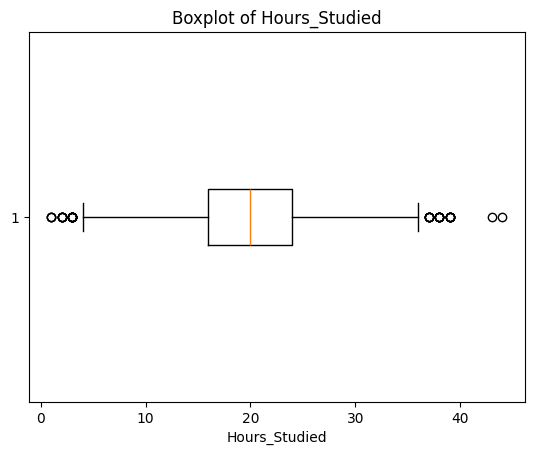

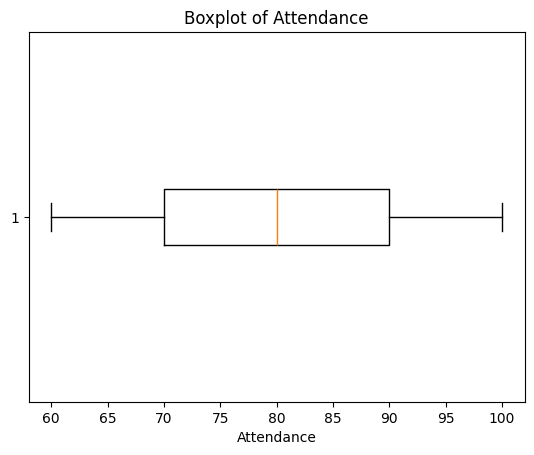

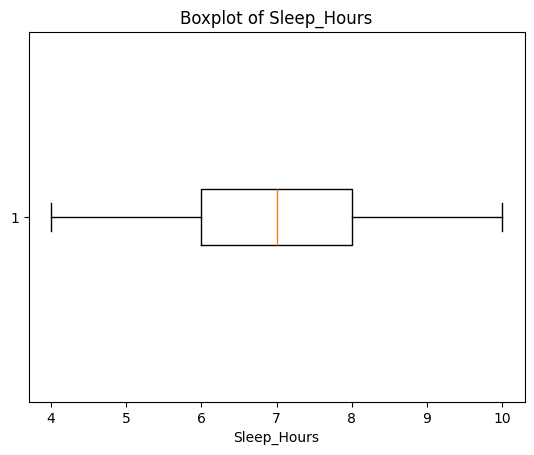

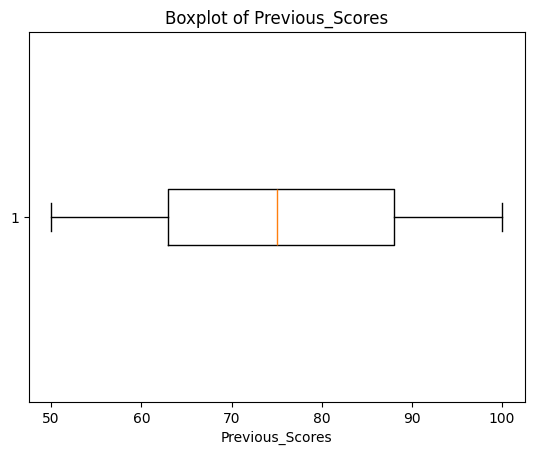

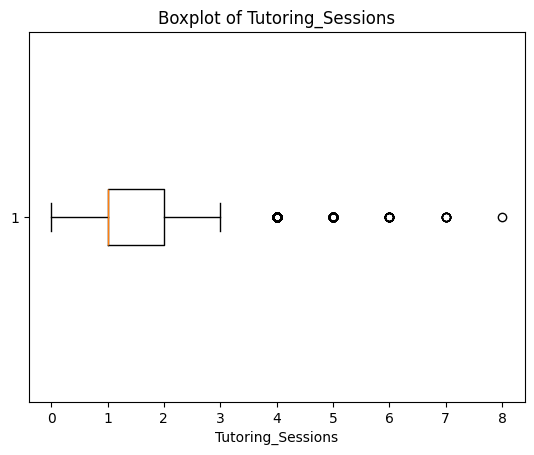

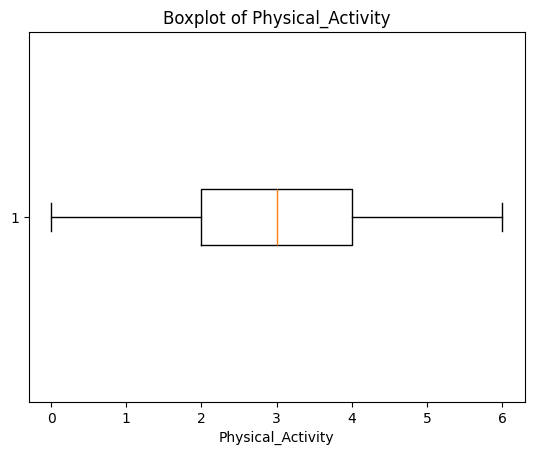

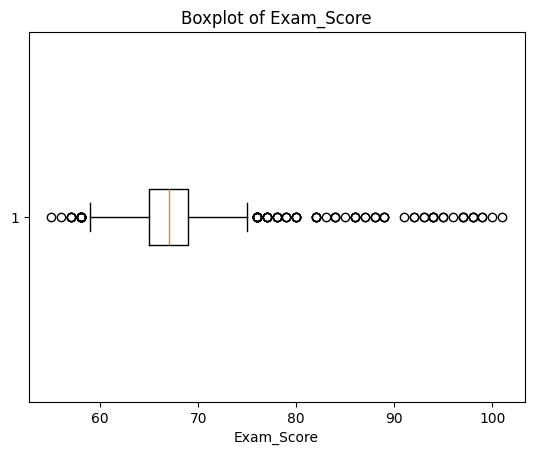

In [ ]:
numeric_cols = df.select_dtypes(include=[np.number]).columns

print("[Before Removing Outliers]")

for col in numeric_cols:
    plt.figure()
    plt.boxplot(df[col], vert=False)
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.show()

In [ ]:
Q1 = df["Exam_Score"].quantile(0.25)
Q3 = df["Exam_Score"].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
df = df[(df["Exam_Score"] >= lower) & (df["Exam_Score"] <= upper)]


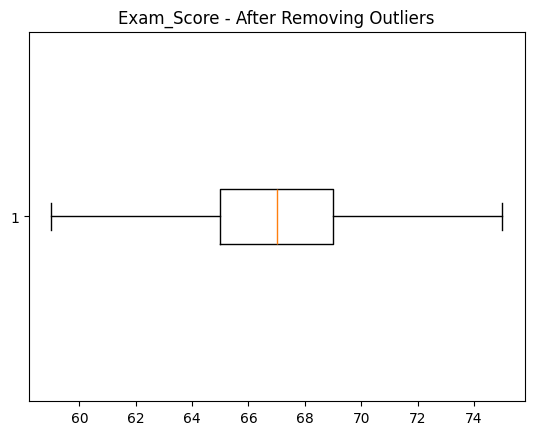

In [ ]:
plt.boxplot(df["Exam_Score"], vert=False)
plt.title("Exam_Score - After Removing Outliers")
plt.show()

**4) Target distribution (EDA)**

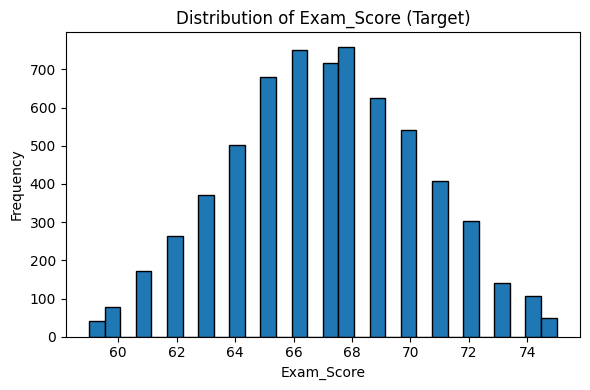

In [ ]:
plt.figure(figsize=(6,4))
plt.hist(df["Exam_Score"], bins=30, edgecolor="black")
plt.title("Distribution of Exam_Score (Target)")
plt.xlabel("Exam_Score")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

**5) Correlation heatmap (EDA)**

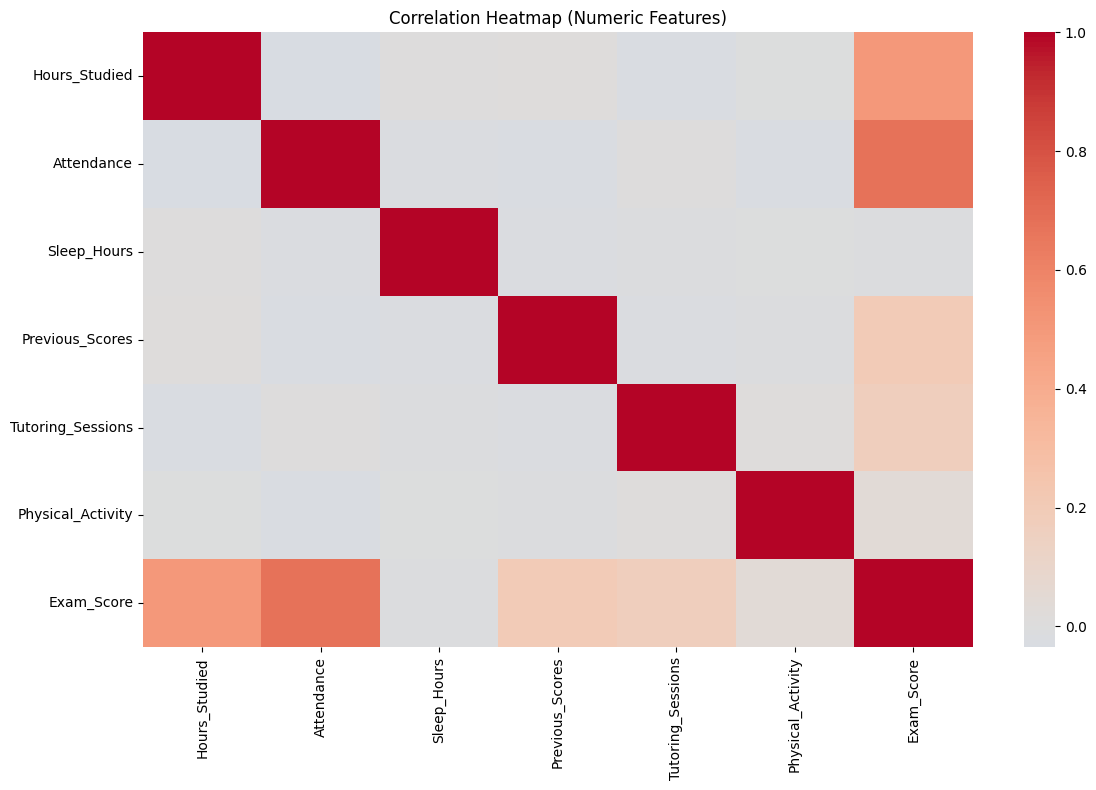

In [ ]:
# correlation on numeric columns only
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap (Numeric Features)")
plt.tight_layout()
plt.show()


=== Top 4 Correlated Features with Exam_Score ===
['Attendance', 'Hours_Studied', 'Previous_Scores', 'Tutoring_Sessions']


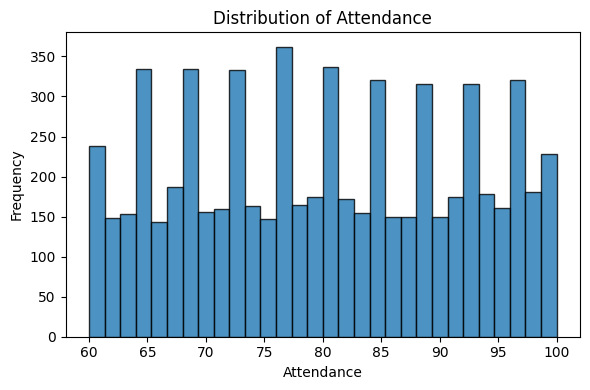

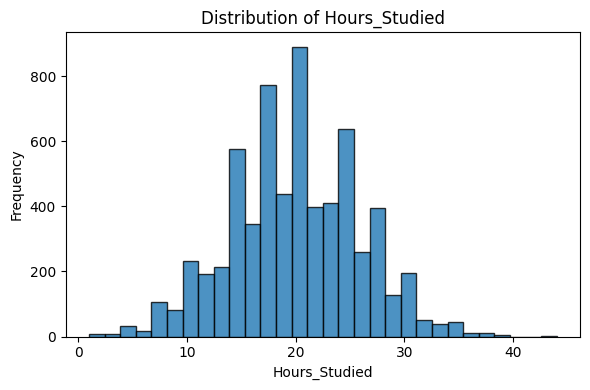

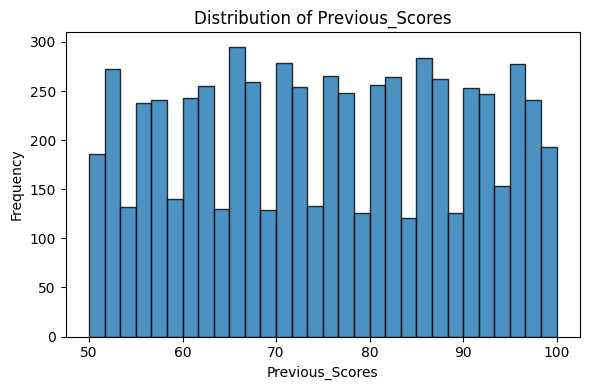

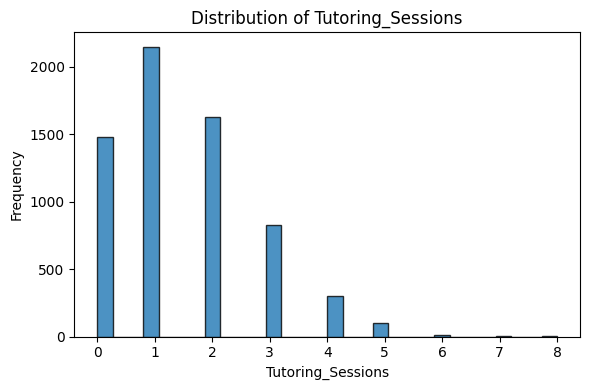

In [ ]:
#Feature Selection with heatmap
corr_with_target = corr["Exam_Score"].drop("Exam_Score").abs().sort_values(ascending=False)
top4_features = corr_with_target.head(4).index.tolist()

print("\n=== Top 4 Correlated Features with Exam_Score ===")
print(top4_features)

for col in top4_features:
    plt.figure(figsize=(6,4))
    plt.hist(df[col], bins=30, edgecolor="black", alpha=0.8)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

**6) Split data**

In [ ]:
X = df.drop("Exam_Score", axis=1)
y = df["Exam_Score"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

**7) Preprocessing**

In [ ]:
numeric_features = X.select_dtypes(include=[np.number]).columns
categorical_features = X.select_dtypes(exclude=[np.number]).columns

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),  #insert median number to NaN value
    ("scaler", StandardScaler())                    #Scaler : Transform range the number to [0...1]
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")), #insert most frequent to NaN value
    ("onehot", OneHotEncoder(handle_unknown="ignore"))    #ُEncoder : Transform categorical to number value
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

**8) Models (4 regression models)**

In [ ]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

**9) Train + Evaluate each model**

In [ ]:

from sklearn.metrics import mean_squared_error, r2_score

rmse = lambda y_true, y_pred: np.sqrt(mean_squared_error(y_true, y_pred))

results = []

for name, model in models.items():
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    results.append([
        name,
        rmse(y_test, y_pred),
        r2_score(y_test, y_pred)
    ])

results_df = pd.DataFrame(results, columns=["Model", "RMSE", "R2"])

print("\n=== Results (4 Models) ===")
print(results_df.sort_values("RMSE"))




=== Results (4 Models) ===
               Model      RMSE        R2
0  Linear Regression  0.327374  0.989703
1   Ridge Regression  0.327377  0.989703
3  Gradient Boosting  0.784123  0.940926
2      Random Forest  1.079528  0.888031


**Ensemble: Voting Regressor**

In [ ]:
voting = VotingRegressor([
    ("rf", Pipeline(steps=[("preprocessor", preprocessor),
                           ("model", RandomForestRegressor(random_state=42))])),

    ("gbr", Pipeline(steps=[("preprocessor", preprocessor),
                            ("model", GradientBoostingRegressor(random_state=42))])),

    ("ridge", Pipeline(steps=[("preprocessor", preprocessor),
                              ("model", Ridge())]))
])

voting.fit(X_train, y_train)
pred_vote = voting.predict(X_test)
rmse_vote = rmse(y_test, pred_vote)
r2_vote = r2_score(y_test, pred_vote)

print("\n=== Voting Regressor ===")
print("Voting RMSE:", rmse_vote)
print("Voting R2  :", r2_vote)



=== Voting Regressor ===
Voting RMSE: 0.6501636365640792
Voting R2  : 0.9593858832136578


**11) Hyperparameter tuning (GridSearch) - Ridge**

In [ ]:
ridge_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", Ridge())
])

param_grid = {
    "model__alpha": [0.1, 1, 10, 50, 100]
}

gs = GridSearchCV(
    ridge_pipe,
    param_grid=param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error"
)

gs.fit(X_train, y_train)
best_model = gs.best_estimator_

pred_best = best_model.predict(X_test)
rmse_best = rmse(y_test, pred_best)
r2_best = r2_score(y_test, pred_best)

print("\n=== Tuned Ridge (GridSearch) ===")
print("Best alpha:", gs.best_params_)
print("Tuned Ridge RMSE:", rmse_best)
print("Tuned Ridge R2  :", r2_best)


=== Tuned Ridge (GridSearch) ===
Best alpha: {'model__alpha': 0.1}
Tuned Ridge RMSE: 0.32737405699269656
Tuned Ridge R2  : 0.9897027754746843


In [ ]:
from sklearn.model_selection import GridSearchCV

rf_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(random_state=42))
])

rf_param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 10, 20]
}

rf_gs = GridSearchCV(
    rf_pipe,
    param_grid=rf_param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error"
)

rf_gs.fit(X_train, y_train)

best_rf = rf_gs.best_estimator_
pred_rf = best_rf.predict(X_test)

rmse_rf_opt = rmse(y_test, pred_rf)
r2_rf_opt = r2_score(y_test, pred_rf)

print("\n=== Optimized Random Forest ===")
print("Best parameters:", rf_gs.best_params_)
print("RMSE:", rmse_rf_opt)
print("R2  :", r2_rf_opt)



=== Optimized Random Forest ===
Best parameters: {'model__max_depth': 20, 'model__n_estimators': 200}
RMSE: 1.0738816859119058
R2  : 0.889198782274907


In [ ]:
gbr_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", GradientBoostingRegressor(random_state=42))
])

gbr_param_grid = {
    "model__n_estimators": [100, 200],
    "model__learning_rate": [0.05, 0.1]
}

gbr_gs = GridSearchCV(
    gbr_pipe,
    param_grid=gbr_param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error"
)

gbr_gs.fit(X_train, y_train)

best_gbr = gbr_gs.best_estimator_
pred_gbr = best_gbr.predict(X_test)

rmse_gbr_opt = rmse(y_test, pred_gbr)
r2_gbr_opt = r2_score(y_test, pred_gbr)

print("\n=== Optimized Gradient Boosting ===")
print("Best parameters:", gbr_gs.best_params_)
print("RMSE:", rmse_gbr_opt)
print("R2  :", r2_gbr_opt)



=== Optimized Gradient Boosting ===
Best parameters: {'model__learning_rate': 0.1, 'model__n_estimators': 200}
RMSE: 0.5175583930507207
R2  : 0.9742634473913463


In [ ]:
from sklearn.model_selection import GridSearchCV

lr_pipe = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

lr_param_grid = {
    "model__fit_intercept": [True, False]
}

lr_gs = GridSearchCV(
    lr_pipe,
    param_grid=lr_param_grid,
    cv=5,
    scoring="neg_root_mean_squared_error"
)

lr_gs.fit(X_train, y_train)

best_lr = lr_gs.best_estimator_
pred_lr = best_lr.predict(X_test)

rmse_lr_opt = rmse(y_test, pred_lr)
r2_lr_opt = r2_score(y_test, pred_lr)

print("\n=== Optimized Linear Regression ===")
print("Best parameters:", lr_gs.best_params_)
print("RMSE:", rmse_lr_opt)
print("R2  :", r2_lr_opt)



=== Optimized Linear Regression ===
Best parameters: {'model__fit_intercept': True}
RMSE: 0.32737395629711513
R2  : 0.9897027818092415


In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

rmse = lambda y_true, y_pred: np.sqrt(mean_squared_error(y_true, y_pred))

optimized_models = {
    "Tuned Ridge Regression": best_model,
    "Optimized Random Forest": best_rf,
     "Optimized Gradient Boosting": best_gbr
}

optimized_results = []

for name, model in optimized_models.items():
    y_pred = model.predict(X_test)

    optimized_results.append([
        name,
        rmse(y_test, y_pred),
        r2_score(y_test, y_pred)
    ])

optimized_results_df = pd.DataFrame(
    optimized_results,
    columns=["Model", "RMSE", "R2"]
)

print("\n=== Optimized Regression Models Results ===")
print(optimized_results_df.sort_values("RMSE"))



=== Optimized Regression Models Results ===
                         Model      RMSE        R2
0       Tuned Ridge Regression  0.327374  0.989703
2  Optimized Gradient Boosting  0.517558  0.974263
1      Optimized Random Forest  1.073882  0.889199


**Overfitting / Underfitting check (Train vs Test)**

In [ ]:
pred_train_best = best_model.predict(X_train)
pred_test_best  = best_model.predict(X_test)

print("\n=== Overfitting Check (Tuned Ridge) ===")
print("Train RMSE:", rmse(y_train, pred_train_best))
print("Test  RMSE:", rmse(y_test, pred_test_best))
print("Train R2  :", r2_score(y_train, pred_train_best))
print("Test  R2  :", r2_score(y_test, pred_test_best))



=== Overfitting Check (Tuned Ridge) ===
Train RMSE: 0.3259474114480423
Test  RMSE: 0.32737405699269656
Train R2  : 0.9899569032162806
Test  R2  : 0.9897027754746843


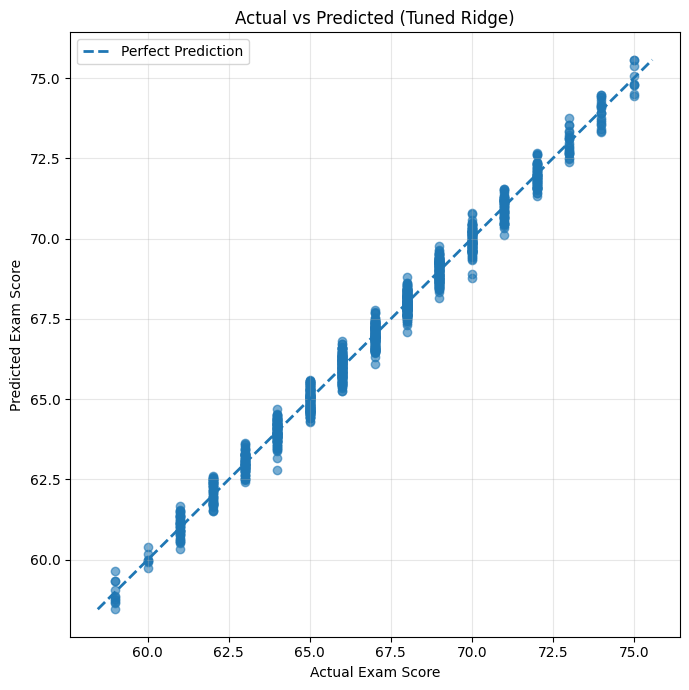

In [ ]:
# Actual vs Predicted plot (Evaluation visualization)
plt.figure(figsize=(7, 7))
plt.scatter(y_test, pred_best, alpha=0.6)

min_val = min(y_test.min(), pred_best.min())
max_val = max(y_test.max(), pred_best.max())

plt.plot([min_val, max_val], [min_val, max_val],
         linestyle="--", linewidth=2, label="Perfect Prediction")

plt.xlabel("Actual Exam Score")
plt.ylabel("Predicted Exam Score")
plt.title("Actual vs Predicted (Tuned Ridge)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


**12) Final comparison table**

In [ ]:
final_table = pd.DataFrame([
    ["Linear Regression", results_df.loc[results_df["Model"]=="Linear Regression","RMSE"].values[0],
                        results_df.loc[results_df["Model"]=="Linear Regression","R2"].values[0]],
    ["Ridge Regression",  results_df.loc[results_df["Model"]=="Ridge Regression","RMSE"].values[0],
                        results_df.loc[results_df["Model"]=="Ridge Regression","R2"].values[0]],
    ["Random Forest",     results_df.loc[results_df["Model"]=="Random Forest","RMSE"].values[0],
                        results_df.loc[results_df["Model"]=="Random Forest","R2"].values[0]],
    ["Gradient Boosting", results_df.loc[results_df["Model"]=="Gradient Boosting","RMSE"].values[0],
                        results_df.loc[results_df["Model"]=="Gradient Boosting","R2"].values[0]],
    ["Voting Regressor",  rmse_vote, r2_vote],
    ["Tuned Ridge",       rmse_best, r2_best],
], columns=["Model", "RMSE", "R2"]).sort_values(by="RMSE")

print("\n=== Final Comparison Table ===")
print(final_table)


=== Final Comparison Table ===
               Model      RMSE        R2
0  Linear Regression  0.327374  0.989703
5        Tuned Ridge  0.327374  0.989703
1   Ridge Regression  0.327377  0.989703
4   Voting Regressor  0.650164  0.959386
3  Gradient Boosting  0.784123  0.940926
2      Random Forest  1.079528  0.888031
